# Bayesian vs. Frequentist Analysis of Proportions
## California School Pass Rates (the `star98` dataset)

303 California school districts, bundled inside `statsmodels`
(`statsmodels.datasets.star98`). For each district: `NABOVE` (students scoring above the
national median on a reading test) and `NBELOW` (at or below it) -- each student's outcome is a
Bernoulli trial, and a district's pass *rate* is the parameter `p` to estimate.

**Setup (run once, then restart the runtime -- Runtime -> Restart session in Colab):**


In [1]:
!pip install -q pymc==6.3.1 arviz==1.3.0 statsmodels==0.14.6 scipy==1.16.1



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import arviz as az
import pymc as pm
import statsmodels.api as sm

RNG = np.random.default_rng(2024)

from IPython.display import SVG, display

def show_graph(model):
    """pm.model_to_graphviz needs the Graphviz `dot` binary on PATH to actually
    render an image (present by default on Colab; not guaranteed on every machine).
    Try to render it, and fall back to a plain description instead of crashing the
    notebook if the binary isn't installed here."""
    g = pm.model_to_graphviz(model)
    try:
        display(SVG(g.pipe(format="svg")))
    except Exception as e:
        print(f"(Graphviz's 'dot' binary isn't available in this environment, so the "
              f"diagram can't be rendered here -- run '!apt-get install -y graphviz' "
              f"first if this happens on Colab. Underlying error: {e})")
        print(g.source)


g++ not available, if using conda: `conda install gxx`


## The dataset

**Chat, what is the `star98` dataset, and is it a good fit for modeling binomial proportions?**

> `star98` comes from a study of California school districts and their scores on a
> standardized reading test. For each district it records `NABOVE` and `NBELOW`: the number of
> students who scored above vs. at-or-below the national median. It also carries district-level
> covariates (poverty rate, teacher experience, spending per student, etc.) which is why
> `statsmodels` ships it as a worked example for binomial GLMs (`sm.GLM` with a `Binomial`
> family). For our purposes we only need `NABOVE`/`NBELOW`: each is a real aggregated count of
> Bernoulli trials (one per student). It is a good fit precisely because it is *real* count data
> with heterogeneous sample sizes.


In [3]:
star = sm.datasets.star98.load_pandas().data
star["N"] = star["NABOVE"] + star["NBELOW"]
star["rate"] = star["NABOVE"] / star["N"]
print(star.shape)
star[["NABOVE", "NBELOW", "N", "rate"]].describe()


(303, 24)


,NABOVE,NBELOW,N,rate
count,303.000000,303.000000,303.000000,303.000000
mean,357.815182,525.389439,883.204620,0.436978
std,660.911376,1771.323315,2377.551861,0.184236
min,4.000000,14.000000,33.000000,0.075758
25%,72.500000,98.000000,187.500000,0.290816
50%,199.000000,212.000000,445.000000,0.431818
75%,421.000000,542.500000,1020.000000,0.552178
max,9324.000000,29528.000000,38852.000000,0.928302


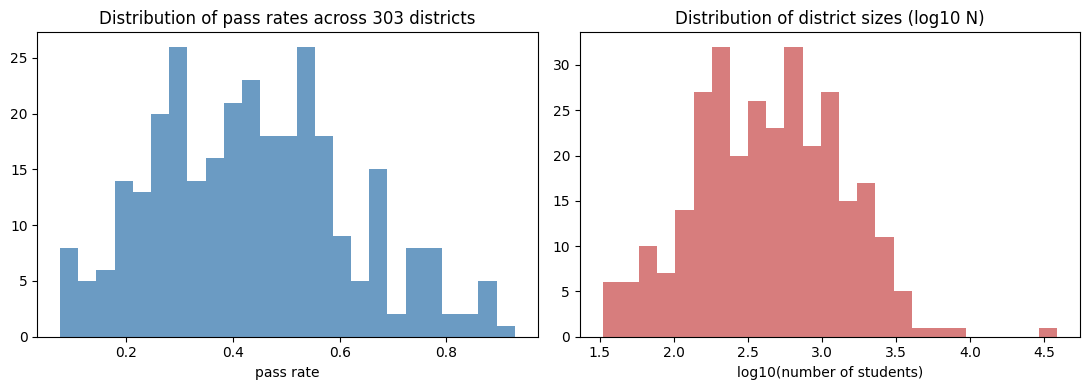

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(star["rate"], bins=25, color="steelblue", alpha=0.8)
ax[0].set_title("Distribution of pass rates across 303 districts")
ax[0].set_xlabel("pass rate")
ax[1].hist(np.log10(star["N"]), bins=25, color="indianred", alpha=0.8)
ax[1].set_title("Distribution of district sizes (log10 N)")
ax[1].set_xlabel("log10(number of students)")
plt.tight_layout()
plt.show()


## A single district: the frequentist answer


In [5]:
median_idx = (star["N"] - star["N"].median()).abs().idxmin()
district = star.loc[median_idx]
n_above, n_below, n_total = int(district["NABOVE"]), int(district["NBELOW"]), int(district["N"])
print(f"Chosen district #{median_idx}: {n_above} above / {n_below} below out of {n_total} students")

data = np.array([1] * n_above + [0] * n_below)
RNG.shuffle(data)
p_hat = data.mean()
print("p_hat =", p_hat)


Chosen district #172: 276 above / 169 below out of 445 students
p_hat = 0.6202247191011236


In [6]:
# Wald (normal-approximation) CI -- the textbook formula
se = np.sqrt(p_hat * (1 - p_hat) / n_total)
wald_lo, wald_hi = p_hat - 1.96 * se, p_hat + 1.96 * se

# Bootstrap CI, exactly as in the lecturer's notebook
boot = stats.bootstrap((data,), np.mean, confidence_level=0.95, n_resamples=5000, random_state=0)
boot_lo, boot_hi = boot.confidence_interval

# Wilson score CI -- the "better" classical interval for proportions
wilson_lo, wilson_hi = sm.stats.proportion_confint(n_above, n_total, alpha=0.05, method="wilson")

print(f"Wald CI:    [{wald_lo:.4f}, {wald_hi:.4f}]")
print(f"Bootstrap:  [{boot_lo:.4f}, {boot_hi:.4f}]")
print(f"Wilson CI:  [{wilson_lo:.4f}, {wilson_hi:.4f}]")


Wald CI:    [0.5751, 0.6653]
Bootstrap:  [0.5730, 0.6629]
Wilson CI:  [0.5743, 0.6641]


**Chat, discuss the differences between Bayesian and frequentist statistics, using this example
of estimating a school's pass rate.**

> The frequentist point estimate `p_hat` treats the true pass rate as a fixed, unknown constant,
> and quantifies uncertainty by asking "if I repeated this sampling many times, what range of
> `p_hat` values would I see?" -- the randomness lives in the *data*, and the confidence interval
> is a statement about the *procedure* (95% of such intervals would contain the true `p`), not
> about `p` itself for this one district.
>
> The Bayesian approach instead treats `p` itself as a random variable with a probability
> distribution that represents our belief about it, updated via Bayes' rule as data arrives. The
> resulting credible interval (below) *is* a direct probability statement: "given this prior and
> this data, there is a 95% probability the true rate lies in this range." The two often
> numerically agree for large samples with a weak prior, but they answer philosophically
> different questions.


In [7]:
# Coverage simulation: for a small, extreme-p district, how often does each interval
# formula actually contain the true rate across repeated sampling?
small_extreme = star.loc[(star["N"] < 60) & (star["rate"] < 0.2)]
true_p_small = 0.12
n_small = 40

def coverage(method, n_trials=4000):
    hits = 0
    for _ in range(n_trials):
        k = stats.bernoulli.rvs(true_p_small, size=n_small, random_state=RNG).sum()
        if method == "wald":
            ph = k / n_small
            se_ = np.sqrt(ph * (1 - ph) / n_small) if 0 < ph < 1 else 0
            lo, hi = ph - 1.96 * se_, ph + 1.96 * se_
        else:
            lo, hi = sm.stats.proportion_confint(k, n_small, alpha=0.05, method="wilson")
        hits += lo <= true_p_small <= hi
    return hits / n_trials

wald_cov = coverage("wald")
wilson_cov = coverage("wilson")
print(f"Small districts with a pass rate under 0.2 in our data: {len(small_extreme)}")
print(f"Nominal coverage target: 0.95")
print(f"Wald 95% CI empirical coverage (n={n_small}, true p={true_p_small}):   {wald_cov:.3f}")
print(f"Wilson 95% CI empirical coverage (n={n_small}, true p={true_p_small}): {wilson_cov:.3f}")


Small districts with a pass rate under 0.2 in our data: 2
Nominal coverage target: 0.95
Wald 95% CI empirical coverage (n=40, true p=0.12):   0.862
Wilson 95% CI empirical coverage (n=40, true p=0.12): 0.941


## The Bayesian answer

$$PRIOR(p) = Beta(1,1) = U[0,1]$$


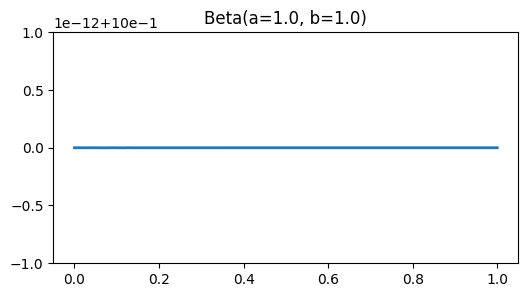

In [8]:
x_grid = np.linspace(0, 1, 400)

def plot_beta(a, b, ax=None, **kw):
    ax = ax or plt.gca()
    ax.plot(x_grid, stats.beta.pdf(x_grid, a, b), lw=2, **kw)
    ax.set_title(f"Beta(a={a:.1f}, b={b:.1f})")

plt.figure(figsize=(6, 3))
plot_beta(1, 1)
plt.show()


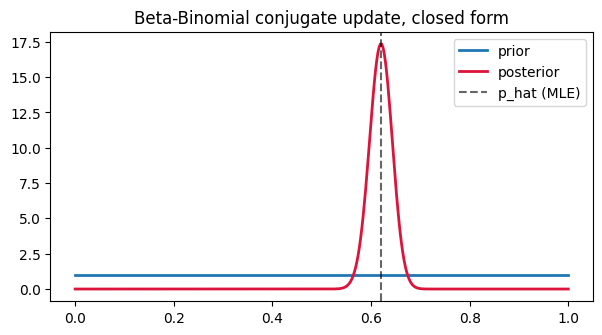

In [9]:
# Conjugate update in closed form: Beta(1,1) + n_above successes, n_below failures
a_post, b_post = 1 + n_above, 1 + n_below

plt.figure(figsize=(7, 3.5))
plot_beta(1, 1, label="prior")
plt.plot(x_grid, stats.beta.pdf(x_grid, a_post, b_post), lw=2, color="crimson", label="posterior")
plt.axvline(p_hat, color="k", ls="--", alpha=0.6, label="p_hat (MLE)")
plt.legend()
plt.title("Beta-Binomial conjugate update, closed form")
plt.show()


**Chat, why is the Beta distribution the natural conjugate prior for a Binomial likelihood?**

> The Binomial likelihood for `k` successes out of `n` trials is proportional to
> `p^k * (1-p)^(n-k)` (as a function of `p`) -- and the Beta density has exactly that algebraic
> form, `p^(a-1) * (1-p)^(b-1)`. Multiplying a `Beta(a, b)` prior by this likelihood just adds the
> exponents: the posterior is `Beta(a + k, b + n - k)`, again a Beta distribution. That closure
> under multiplication (conjugacy) is why we can update the parameters `(a, b)` by simple
> addition instead of doing any numerical integration.


## In PyMC


In [10]:
# Binomial on the aggregate count, mathematically equivalent by sufficiency to a
# per-student pm.Bernoulli array, and far cheaper for large districts.
with pm.Model() as single_model:
    p = pm.Beta("p", alpha=1.0, beta=1.0)
    y = pm.Binomial("y", n=n_total, p=p, observed=n_above)

show_graph(single_model)


(Graphviz's 'dot' binary isn't available in this environment, so the diagram can't be rendered here -- run '!apt-get install -y graphviz' first if this happens on Colab. Underlying error: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH)
digraph {
	p [label="p
~
Beta" shape=ellipse]
	y [label="y
~
Binomial" shape=ellipse style=filled]
	p -> y
}



In [11]:
with single_model:
    idata_single = pm.sample(2000, chains=4, random_seed=2024, progressbar=False)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.


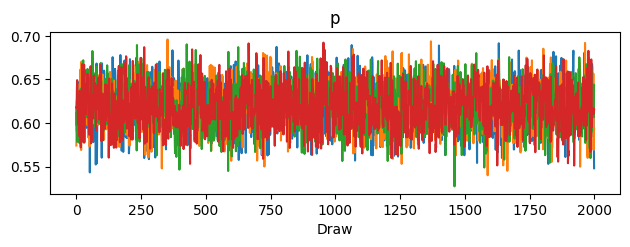

In [12]:
az.plot_trace(idata_single)
plt.tight_layout()
plt.show()


**Chat, is the `pm.Binomial` encoding really identical to a per-student `pm.Bernoulli` array?
Show me, don't just assert it.**

> By the sufficiency of the Binomial count for a Bernoulli sequence, the two encodings should give
> mathematically identical posteriors. Don't just take that on faith: fit the equivalent
> Bernoulli-array model on the same reconstructed 0/1 data and compare the two posteriors' means
> and standard deviations directly.


In [13]:
with pm.Model() as single_model_bernoulli:
    p_b = pm.Beta("p", alpha=1.0, beta=1.0)
    y_b = pm.Bernoulli("y", p=p_b, observed=data)
    idata_bernoulli = pm.sample(2000, chains=4, random_seed=2024, progressbar=False)

print("Binomial-encoding posterior mean: ", idata_single.posterior["p"].mean().item())
print("Bernoulli-encoding posterior mean:", idata_bernoulli.posterior["p"].mean().item())
print("Binomial-encoding posterior sd:   ", idata_single.posterior["p"].std().item())
print("Bernoulli-encoding posterior sd:  ", idata_bernoulli.posterior["p"].std().item())


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


Binomial-encoding posterior mean:  0.6193675438226235
Bernoulli-encoding posterior mean: 0.6193675438237829
Binomial-encoding posterior sd:    0.023084849952401773
Bernoulli-encoding posterior sd:   0.023084849989931926


**Chat, explain the output of `pm.sample()`, and what would change if we used the per-student
Bernoulli array instead.**

> `pm.sample()` runs the No-U-Turn Sampler (NUTS), an adaptive Hamiltonian Monte Carlo algorithm,
> across 4 independent chains, each producing 2000 post-warm-up draws from the posterior of `p`.
> The trace plot's left panel is the posterior density estimated from those draws (one curve per
> chain -- they should overlap almost perfectly if sampling went well); the right panel is the raw
> sample path over iterations (it should look like structureless noise, not a wandering trend).
> Swapping in the length-`n_total` Bernoulli array would produce the *same* posterior (by
> sufficiency) but a slower likelihood evaluation per step, since PyMC would evaluate `n_total`
> Bernoulli log-probabilities instead of one Binomial log-probability at every leapfrog step of
> NUTS.


## Credible intervals vs. classical confidence intervals


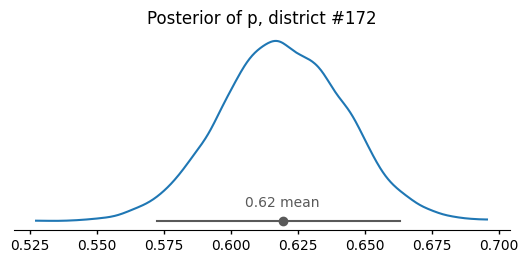

In [14]:
# az.plot_posterior() no longer exists in this arviz version -- folded into az.plot_dist().
az.plot_dist(idata_single, var_names=["p"], ci_kind="hdi", ci_prob=0.95, point_estimate="mean")
plt.title("Posterior of p, district #{}".format(median_idx))
plt.show()


In [15]:
hdi = az.hdi(idata_single, var_names=["p"], prob=0.95)["p"].values
summary_single = az.summary(idata_single, ci_prob=0.95)
print(summary_single)
print()
print(f"Wald CI       : [{wald_lo:.4f}, {wald_hi:.4f}]")
print(f"Bootstrap CI  : [{boot_lo:.4f}, {boot_hi:.4f}]")
print(f"Wilson CI     : [{wilson_lo:.4f}, {wilson_hi:.4f}]")
print(f"Bayesian HDI  : [{hdi[0]:.4f}, {hdi[1]:.4f}]")


     mean      sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
p  0.6194  0.0231     0.57     0.66     3331     4257  1.00    0.0004  0.00028

Wald CI       : [0.5751, 0.6653]
Bootstrap CI  : [0.5730, 0.6629]
Wilson CI     : [0.5743, 0.6641]
Bayesian HDI  : [0.5726, 0.6631]


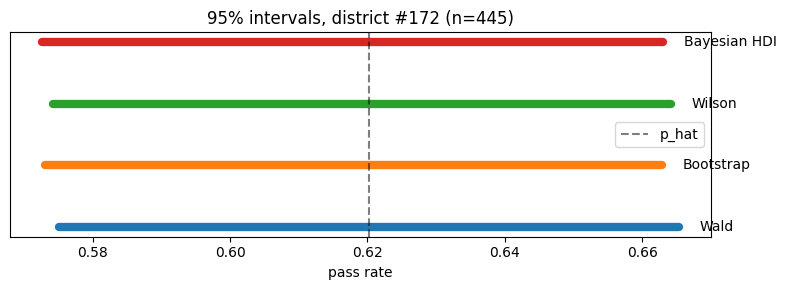

In [16]:
fig, ax = plt.subplots(figsize=(8, 3))
intervals = [
    ("Wald", wald_lo, wald_hi),
    ("Bootstrap", boot_lo, boot_hi),
    ("Wilson", wilson_lo, wilson_hi),
    ("Bayesian HDI", hdi[0], hdi[1]),
]
for i, (name, lo, hi) in enumerate(intervals):
    ax.plot([lo, hi], [i, i], lw=6, solid_capstyle="round")
    ax.text(hi + 0.003, i, name, va="center")
ax.axvline(p_hat, color="k", ls="--", alpha=0.5, label="p_hat")
ax.set_yticks([])
ax.set_xlabel("pass rate")
ax.set_title(f"95% intervals, district #{median_idx} (n={n_total})")
ax.legend()
plt.tight_layout()
plt.show()


### Hypothesis testing: Bayes factor vs. classical test

**Chat, what's the Bayes factor and how does it compare to a classical significance test here?
What are H0 and H1, and how does arviz compute it?**

> Suppose we ask "is this district's pass rate different from the statewide average?" -- a natural
> reference value, more meaningful here than an arbitrary 0.5. The classical answer is a
> hypothesis test (`H0: p = p_state` vs. `H1: p != p_state`), summarized by a p-value: the
> probability of seeing data this extreme *if H0 were exactly true*. The Bayesian alternative is
> the Bayes factor, which directly compares the *evidence* for H0 against H1 by contrasting the
> posterior density at the reference value to the prior density there -- the **Savage-Dickey
> density ratio**. Intuitively: if the data pulled the posterior mass strongly away from the
> reference value relative to where the prior put it, that is evidence against H0. `arviz`'s
> `plot_bf` computes exactly this ratio using the posterior samples and a reference (or resampled
> prior) distribution.


In [17]:
state_avg = star["rate"].mean()
print("Statewide average pass rate:", round(state_avg, 4))

# Classical: an exact binomial test against the state average
btest = stats.binomtest(n_above, n_total, p=state_avg)
print("Classical binomial test p-value:", btest.pvalue)


Statewide average pass rate: 0.437
Classical binomial test p-value: 1.0565671884375484e-14


Sampling: [p, y]


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\bayes_factor.py:87: UserWarning: Reference value 0.43697839965905794 for 'p' is outside the posterior range. This may overstate evidence in favor of H1.
  warnings.warn(


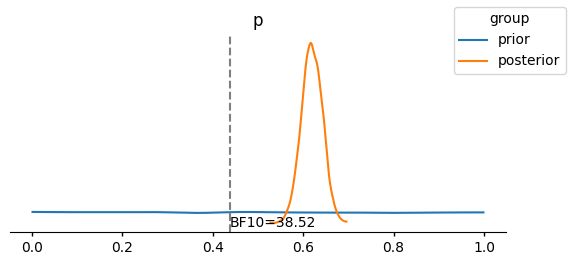

In [18]:
# az.plot_bf reads the prior from an InferenceData "prior" group, so we draw real
# prior-predictive samples from the model (its prior on p is exactly Beta(1,1) = U[0,1])
# rather than hand-rolling a uniform array.
with single_model:
    prior_pred = pm.sample_prior_predictive(10_000, random_seed=2024)
idata_single["prior"] = prior_pred["prior"]

az.plot_bf(idata_single, var_names="p", ref_val=state_avg)
plt.show()


**Chat, how should I interpret the Bayes factor value above, and why might it disagree with the
p-value?**

> A common (Jeffreys-style) scale: BF10 between 1-3 is "barely worth mentioning," 3-10
> "substantial," 10-30 "strong," 30-100 "very strong," and above 100 "decisive" evidence for H1
> over H0 (and symmetrically for BF01 favoring H0). Bayes factors and p-values can disagree,
> sometimes sharply, especially with large sample sizes: a p-value keeps shrinking as `n` grows
> even for a tiny, practically meaningless deviation from H0, while a well-specified Bayes factor
> can still favor H0 if the deviation is small relative to the prior's spread -- this divergence is
> known as **Lindley's paradox**. It's a genuine, structural difference between the two
> frameworks, not a computational quirk.


### Bayes estimators

**Chat, what's the difference between a point estimate and a Bayes estimator, and which loss
function corresponds to the posterior mean vs. the posterior median?**

> A Bayes estimator is the value that minimizes the *posterior expected loss* for a chosen loss
> function: the posterior **mean** minimizes expected squared error (L2 loss), the posterior
> **median** minimizes expected absolute error (L1 loss), and the posterior **mode** minimizes
> expected 0/1 loss. They coincide for a symmetric, unimodal posterior (as here), but can differ
> noticeably for skewed posteriors — e.g. a district with very few students and a pass rate near
> 0, where the Beta posterior is right-skewed.


Minimizer of L2 (posterior mean check): 0.6190476190476191 vs. actual mean: 0.6193675438226235
Minimizer of L1 (posterior median check): 0.6190476190476191 vs. actual median: 0.6191975647201309


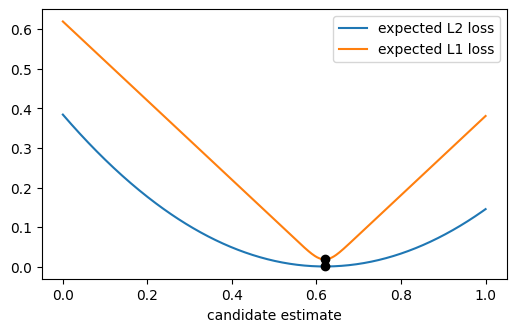

In [19]:
post_p = idata_single.posterior["p"].values.reshape(-1)
grid = np.linspace(0, 1, 400)
L2 = np.mean((post_p.reshape(-1, 1) - grid.reshape(1, -1)) ** 2, axis=0)
L1 = np.mean(np.abs(post_p.reshape(-1, 1) - grid.reshape(1, -1)), axis=0)

print("Minimizer of L2 (posterior mean check):", grid[L2.argmin()], "vs. actual mean:", post_p.mean())
print("Minimizer of L1 (posterior median check):", grid[L1.argmin()], "vs. actual median:", np.median(post_p))

plt.figure(figsize=(6, 3.5))
plt.plot(grid, L2, label="expected L2 loss")
plt.plot(grid, L1, label="expected L1 loss")
plt.scatter([grid[L2.argmin()], grid[L1.argmin()]], [L2.min(), L1.min()], color="k", zorder=5)
plt.legend()
plt.xlabel("candidate estimate")
plt.show()


### Posterior predictive check

**Chat, what's the difference between the posterior and the posterior predictive distribution,
using this district as the example?**

> The posterior, `p(p | data)`, describes our updated belief about the *parameter*. The posterior
> predictive, `p(y_new | data) = integral p(y_new | p) * p(p | data) dp`, describes our belief
> about a *new observation* (e.g. "if we tested another batch of students from this district, how
> many would pass?") -- it accounts for both our uncertainty about `p` and the residual sampling
> randomness of a new Binomial draw given `p`. It is strictly more spread out than the sampling
> distribution at the posterior mean alone, because it also propagates our uncertainty about `p`
> itself.


Sampling: [y]


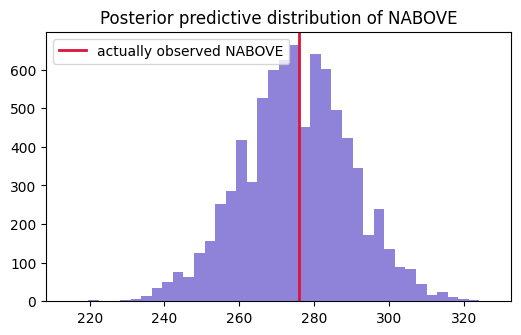

In [20]:
with single_model:
    ppc = pm.sample_posterior_predictive(idata_single, extend_inferencedata=True, progressbar=False)

pred_counts = ppc.posterior_predictive["y"].values.reshape(-1)
plt.figure(figsize=(6, 3.5))
plt.hist(pred_counts, bins=40, color="slateblue", alpha=0.75)
plt.axvline(n_above, color="crimson", lw=2, label="actually observed NABOVE")
plt.legend()
plt.title("Posterior predictive distribution of NABOVE")
plt.show()


## Many districts: independent vs. hierarchical models


In [21]:
star_sorted = star.sort_values("N").reset_index(drop=True)
pick_idx = np.linspace(0, len(star_sorted) - 1, 10).round().astype(int)
subset = star_sorted.loc[pick_idx, ["NABOVE", "NBELOW", "N", "rate"]].reset_index(drop=True)
subset.index.name = "district"
subset


,NABOVE,NBELOW,N,rate
district,,,,
0,13.0,20.0,33.0,0.393939
1,64.0,51.0,115.0,0.556522
2,96.0,78.0,174.0,0.551724
3,93.0,145.0,238.0,0.390756
4,154.0,195.0,349.0,0.441261
5,104.0,446.0,550.0,0.189091
6,465.0,262.0,727.0,0.639615
7,185.0,903.0,1088.0,0.170037
8,368.0,1382.0,1750.0,0.210286


In [22]:
n_districts = len(subset)
successes = subset["NABOVE"].values.astype(int)
totals = subset["N"].values.astype(int)


### Independent model — one free `p` per district, no pooling


In [23]:
with pm.Model() as indep_model:
    p_ind = pm.Beta("p", alpha=1.0, beta=1.0, shape=n_districts)
    y_ind = pm.Binomial("y", n=totals, p=p_ind, observed=successes)
show_graph(indep_model)


(Graphviz's 'dot' binary isn't available in this environment, so the diagram can't be rendered here -- run '!apt-get install -y graphviz' first if this happens on Colab. Underlying error: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH)
digraph {
	subgraph cluster10 {
		p [label="p
~
Beta" shape=ellipse]
		y [label="y
~
Binomial" shape=ellipse style=filled]
		label=10 labeljust=r labelloc=b style=rounded
	}
	p -> y
}



In [24]:
with indep_model:
    idata_ind = pm.sample(2000, chains=4, random_seed=2024, progressbar=False)
    # version note: passing log_likelihood via idata_kwargs is deprecated in this pymc
    # version (FutureWarning) in favor of computing it explicitly, after sampling.
    pm.compute_log_likelihood(idata_ind)
az.summary(idata_ind, ci_prob=0.95)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 13 seconds.


Output()

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p[0],0.401,0.082,0.25,0.57,9918,6275,1.00,0.00082,0.00058
p[1],0.5561,0.0461,0.47,0.65,10645,6198,1.00,0.00045,0.00031
p[2],0.5511,0.0376,0.48,0.62,9322,6063,1.00,0.00039,0.00028
p[3],0.3911,0.0314,0.33,0.45,10582,6267,1.00,0.00031,0.00021
p[4],0.4416,0.0268,0.39,0.49,10445,5932,1.00,0.00026,0.00019
p[5],0.1904,0.0165,0.16,0.22,10690,6431,1.00,0.00016,0.00012
p[6],0.639,0.0178,0.6,0.67,10408,6614,1.00,0.00017,0.00012
p[7],0.1706,0.0114,0.15,0.19,10594,6398,1.00,0.00011,7.8e-05
p[8],0.2106,0.0097,0.19,0.23,10343,6563,1.00,9.5e-05,6.8e-05
p[9],0.24004,0.00218,0.24,0.24,11248,6701,1.00,2.1e-05,1.5e-05


## Comparing two specific districts: contingency tests vs. a Bayesian posterior difference

**Chat, what's the test statistic in Fisher's exact test, and why are its "marginals" fixed?**

> Fisher's exact test conditions on both the row totals (each district's total number of
> students) and the column totals (grand total passing vs. not) being fixed, and then computes
> the exact probability, under the hypergeometric distribution, of every possible table at least
> as extreme as the observed one, given those fixed margins -- hence "exact," no large-sample
> approximation is involved. Fixing the row margins is natural here (each district's `N` is simply
> how many students it has, not something random); fixing the column margin is more of a
> mathematical convenience than a substantive assumption, but the test is standard practice and
> matches the chi-squared test closely whenever expected cell counts aren't tiny.


In [25]:
i, j = 6, 7
contingency = np.array([
    [successes[i], totals[i] - successes[i]],
    [successes[j], totals[j] - successes[j]],
])
print(f"District {i}: {successes[i]} passed / {totals[i] - successes[i]} did not (rate {subset.loc[i, 'rate']:.3f})")
print(f"District {j}: {successes[j]} passed / {totals[j] - successes[j]} did not (rate {subset.loc[j, 'rate']:.3f})")
print(contingency)

odds_ratio, p_fisher = stats.fisher_exact(contingency)
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nFisher's exact test: odds ratio = {odds_ratio:.3f}, p-value = {p_fisher:.2e}")
print(f"Chi-squared test:    chi2 = {chi2:.1f} (df={dof}), p-value = {p_chi2:.2e}")


District 6: 465 passed / 262 did not (rate 0.640)
District 7: 185 passed / 903 did not (rate 0.170)
[[465 262]
 [185 903]]

Fisher's exact test: odds ratio = 8.663, p-value = 3.19e-94
Chi-squared test:    chi2 = 416.0 (df=1), p-value = 1.81e-92


**Chat, what's an odds ratio, and what are the assumptions of the chi-squared test here?**

> The odds ratio compares the odds of passing in district `i` (successes/failures) to the odds of
> passing in district `j`; a value far from 1 means the two districts' pass odds differ
> substantially, and `H0` for both tests is exactly "odds ratio = 1," i.e. the two districts share
> the same underlying pass rate. The chi-squared test additionally assumes the expected count in
> every cell of the table is reasonably large (a common rule of thumb: at least 5) -- with two
> districts this large, that assumption holds comfortably, which is exactly why the chi-squared
> and Fisher's-exact p-values above are close to each other.


In [26]:
p_post = idata_ind.posterior["p"].values  # shape: (chain, draw, district)
diff = p_post[:, :, i].reshape(-1) - p_post[:, :, j].reshape(-1)

diff_lo, diff_hi = az.hdi(diff, prob=0.95, axis=0)
prob_i_greater = (diff > 0).mean()

print(f"Posterior mean of p[{i}] - p[{j}]: {diff.mean():.3f}")
print(f"95% HDI of the difference:        [{diff_lo:.3f}, {diff_hi:.3f}]")
print(f"Posterior probability that district {i}'s rate is higher: {prob_i_greater:.4f}")


Posterior mean of p[6] - p[7]: 0.468
95% HDI of the difference:        [0.425, 0.507]
Posterior probability that district 6's rate is higher: 1.0000


### Hierarchical model — districts share a common `mu`, `nu` (the shrinkage prior)


In [27]:
with pm.Model() as hier_model:
    mu = pm.Beta("mu", 2.0, 2.0)           # hyperprior on the population-average rate
    nu = pm.HalfNormal("nu", 30)           # hyperprior on the "effective sample size" (concentration)
    p_h = pm.Beta("p", mu=mu, nu=nu, shape=n_districts)
    y_h = pm.Binomial("y", n=totals, p=p_h, observed=successes)
show_graph(hier_model)


(Graphviz's 'dot' binary isn't available in this environment, so the diagram can't be rendered here -- run '!apt-get install -y graphviz' first if this happens on Colab. Underlying error: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH)
digraph {
	nu [label="nu
~
Halfnormal" shape=ellipse]
	mu [label="mu
~
Beta" shape=ellipse]
	subgraph cluster10 {
		p [label="p
~
Beta" shape=ellipse]
		y [label="y
~
Binomial" shape=ellipse style=filled]
		label=10 labeljust=r labelloc=b style=rounded
	}
	nu -> p
	mu -> p
	p -> y
}



In [28]:
with hier_model:
    idata_hier = pm.sample(2000, chains=4, random_seed=2024, progressbar=False)
    pm.compute_log_likelihood(idata_hier)
az.summary(idata_hier, ci_prob=0.95)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, nu, p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 14 seconds.


Output()

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.3811,0.0495,0.29,0.48,10876,6661,1.00,0.00048,0.00036
nu,9.59,3.96,3.7,19,10103,7048,1.00,0.04,0.037
p[0],0.389,0.0735,0.25,0.54,13566,6733,1.00,0.00063,0.00043
p[1],0.5423,0.0453,0.45,0.63,12272,6290,1.00,0.00041,0.00029
p[2],0.5431,0.0374,0.47,0.62,12122,6439,1.00,0.00034,0.00024
p[3],0.3907,0.0304,0.33,0.45,12444,6322,1.00,0.00027,0.0002
p[4],0.4394,0.0257,0.39,0.49,11080,6282,1.00,0.00024,0.00017
p[5],0.1923,0.0166,0.16,0.23,12886,6383,1.00,0.00015,0.0001
p[6],0.6365,0.0181,0.6,0.67,11807,5683,1.00,0.00017,0.00011
p[7],0.1719,0.0112,0.15,0.19,12405,5588,1.00,0.0001,7.2e-05


**Chat, why is the `Beta(mu, nu)` parametrization used here instead of `Beta(alpha, beta)`, and
what does `nu` mean?**

> `alpha` and `beta` don't map onto quantities people reason about directly. The `(mu, nu)`
> reparametrization sets `mu = alpha / (alpha + beta)` (the mean rate) and
> `nu = alpha + beta` (interpretable as a "pseudo sample size": how concentrated the Beta is
> around its mean — larger `nu` means a tighter distribution, exactly like having observed more
> prior "trials"). That makes it natural to put a hyperprior directly on the population mean rate
> (`mu`, itself Beta-distributed on `[0,1]`) and on how much the districts are allowed to vary
> around it (`nu`, constrained positive via a HalfNormal). This is the mechanism that lets
> information flow *between* districts during sampling.


### Shrinkage

**Chat, what is shrinkage, and how does the hierarchical model produce it here?**

> In the independent model, each district's posterior for `p` is informed only by that district's
> own data — a district with 40 students has a wide, weakly-informed posterior. In the
> hierarchical model, every district's posterior is *also* pulled towards the shared population
> mean `mu`, with the strength of that pull governed by how much data the district itself
> contributes relative to `nu`. The practical effect: small-sample districts get pulled
> ("shrunk") substantially towards the group average, while large-sample districts are barely
> moved at all, because their own data already overwhelms the shared prior. This is the same
> mechanism as the James-Stein estimator, discovered decades before hierarchical Bayes made it a
> named modeling choice rather than a strange-looking correction.


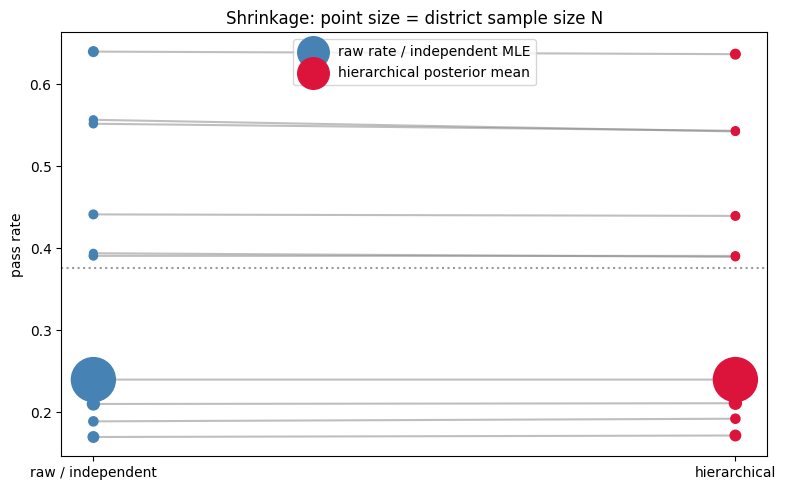

Smallest district (N=33): raw=0.394, hierarchical=0.389
Largest  district (N=38852): raw=0.240, hierarchical=0.240


In [29]:
mean_ind = idata_ind.posterior["p"].mean(dim=("chain", "draw")).values
mean_hier = idata_hier.posterior["p"].mean(dim=("chain", "draw")).values
raw_rate = subset["rate"].values

order = np.argsort(totals)
fig, ax = plt.subplots(figsize=(8, 5))
for rank, i in enumerate(order):
    ax.plot([0, 1], [raw_rate[i], mean_hier[i]], color="gray", alpha=0.5, zorder=1)
ax.scatter(np.zeros(n_districts), raw_rate, s=30 + totals / 40, color="steelblue", label="raw rate / independent MLE", zorder=2)
ax.scatter(np.ones(n_districts), mean_hier, s=30 + totals / 40, color="crimson", label="hierarchical posterior mean", zorder=2)
ax.axhline(mean_hier.mean(), color="k", ls=":", alpha=0.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(["raw / independent", "hierarchical"])
ax.set_ylabel("pass rate")
ax.set_title("Shrinkage: point size = district sample size N")
ax.legend()
plt.tight_layout()
plt.show()

print("Smallest district (N={}): raw={:.3f}, hierarchical={:.3f}".format(totals[order[0]], raw_rate[order[0]], mean_hier[order[0]]))
print("Largest  district (N={}): raw={:.3f}, hierarchical={:.3f}".format(totals[order[-1]], raw_rate[order[-1]], mean_hier[order[-1]]))


### Model comparison: WAIC / LOO

**Chat, I have two Bayesian models for the same data (independent vs. hierarchical) -- how do I
choose between them, and are they nested so I could use a Bayes factor or a classical
likelihood-ratio test instead?**

> They are *not* nested in the classical sense used by a likelihood-ratio test (the hierarchical
> model doesn't reduce to the independent one just by fixing a parameter to zero), and computing
> a Bayes factor between two 10-parameter-vs-12-parameter models here would require the marginal
> likelihood of each, which is generally intractable for models this size. The standard Bayesian
> workaround is an information criterion built from the log pointwise predictive density -- the
> two common choices are WAIC (a fully Bayesian analogue of AIC) and PSIS-LOO (Pareto-smoothed
> importance-sampling leave-one-out cross-validation).


In [30]:
# az.compare(..., ic="waic") raises TypeError in this arviz version -- WAIC was dropped
# entirely and az.compare() now always uses PSIS-LOO.
cmp = az.compare({"independent": idata_ind, "hierarchical": idata_hier})
cmp


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\loo\loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\loo\loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.wa

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
hierarchical,0,0.0,0.0,NaN,,8 k̂ > 0.70,7.8,-44.0,2.9,1.0
independent,1,-1.0,0.8,0.79,N < 100,9 k̂ > 0.70,8.4,-44.0,2.6,0.0


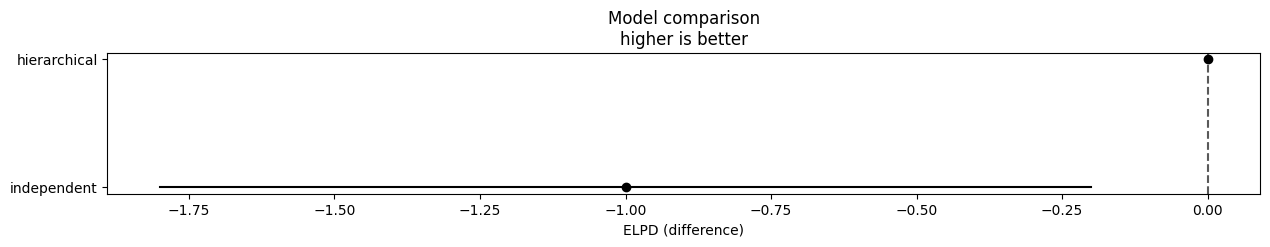

In [31]:
az.plot_compare(cmp)
plt.tight_layout()
plt.show()


In [32]:
loo_hier = az.loo(idata_hier, pointwise=True)
k_hat = loo_hier.pareto_k.values
flagged = subset.reset_index().assign(k_hat=np.round(k_hat, 3))
print("Pareto k-hat per district (sorted by N ascending, so index 9 = largest district):")
print(flagged[["N", "rate", "k_hat"]])
print()
print(f"{(k_hat > 0.7).sum()} out of {len(k_hat)} districts flagged (k-hat > 0.7)")


Pareto k-hat per district (sorted by N ascending, so index 9 = largest district):
         N      rate  k_hat
0     33.0  0.393939  0.658
1    115.0  0.556522  0.948
2    174.0  0.551724  1.010
3    238.0  0.390756  0.991
4    349.0  0.441261  0.744
5    550.0  0.189091  0.802
6    727.0  0.639615  0.985
7   1088.0  0.170037  0.858
8   1750.0  0.210286  0.880
9  38852.0  0.239988  0.643

8 out of 10 districts flagged (k-hat > 0.7)


C:\Users\שקד כהן\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz_stats\loo\loo_helper.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


**Chat, why do we talk about the "effective" number of parameters in WAIC/LOO instead of just
counting them?**

> Both criteria's penalty term estimates how much each parameter *actually* flexes to fit the
> data, not how many parameters exist on paper. In the hierarchical model, the district-level `p`
> values are partially pooled towards `mu` rather than free to fit their district perfectly, so
> each one contributes *less than one* effective parameter — the hierarchical model can have
> nominally more parameters (it adds `mu`, `nu`) yet a lower effective count than the fully
> independent model, which is exactly the mechanism that lets it generalize better despite the
> extra hyperparameters. Plain AIC/BIC, built for fixed-effects models with a well-defined
> parameter count, don't have to reason about this — which is precisely why they are not the
> standard tool for comparing Bayesian hierarchical models.
